# DreamBooth LoRA Fine-Tuning Pipeline

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

FOLDERNAME = 'training_zen/phase2/assignment2_4'
assert FOLDERNAME is not None, "[!] Enter the foldername."

import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

%cd /content/drive/My\ Drive/$FOLDERNAME

Mounted at /content/drive
/content/drive/.shortcut-targets-by-id/1BiuzZ14NaXoAwSCLe-Rgh5bL9BbaSnXz/training_zen/phase2/assignment2_4


In [2]:
print(FOLDERNAME)

training_zen/phase2/assignment2_4


In [3]:
!pip install -q --upgrade-strategy only-if-needed -r requirements.txt
!pip install -q IPython==8.18.1
%load_ext autoreload
%autoreload 2

In [ ]:
import wandb
wandb.login()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: tam-vd230064 (tam-vd230064-hanoi-university-of-science-and-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

: 

In [4]:
import os
os.makedirs("dreamboth-lora-trainer/data/instance_images", exist_ok=True)
os.makedirs("dreamboth-lora-trainer/data/prior_images", exist_ok=True)

In [ ]:
# !python dreamboth-lora-trainer/generate_priors.py --config dreamboth-lora-trainer/training_config.yaml --num_images 100

: 

In [5]:
!pytest dreamboth-lora-trainer/tests/

============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0
rootdir: /content/drive/.shortcut-targets-by-id/1BiuzZ14NaXoAwSCLe-Rgh5bL9BbaSnXz/training_zen/phase2/assignment2_4
plugins: langsmith-0.8.12, anyio-4.13.0, typeguard-4.5.2
collected 2 items                                                              

dreamboth-lora-trainer/tests/test_trainer_behavior.py ..                 [100%]

============================== 2 passed in 14.14s ==============================


In [6]:
!accelerate config default --mixed_precision fp16
!accelerate launch dreamboth-lora-trainer/train.py --config dreamboth-lora-trainer/training_config.yaml

Configuration already exists at /root/.cache/huggingface/accelerate/default_config.yaml, will not override. Run `accelerate config` manually or pass a different `save_location`.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Loading weights: 100% 196/196 [00:00<00:00, 6332.54it/s]
[CLIP] All keys loaded successfully ✅
[VAE] All keys loaded successfully ✅
[UNet] All keys loaded successfully ✅
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb:

In [7]:
import sys
import os
import torch
import yaml
from PIL import Image

sys.path.insert(0, os.path.abspath("."))
sys.path.insert(0, os.path.abspath("dreamboth-lora-trainer"))

from models.stable_diffusion import StableDiffusion
from src.model_utils import inject_lora

device = "cuda" if torch.cuda.is_available() else "cpu"
torch_dtype = torch.float16 if device == "cuda" else torch.float32

sd = StableDiffusion()
sd.load_weight(
    model_id="stable-diffusion-v1-5/stable-diffusion-v1-5",
    device=device,
    quantization="fp16" if device == "cuda" else "fp32"
)

with open("dreamboth-lora-trainer/training_config.yaml", "r") as f:
    config = yaml.safe_load(f)
sd.unet, sd.text_encoder = inject_lora(sd.unet, sd.text_encoder, config)

lora_weights_path = "./checkpoints/final_lora_weights.safetensors"
if not os.path.exists(lora_weights_path):
    lora_weights_path = "./checkpoints/final_lora_weights.bin"

if os.path.exists(lora_weights_path):
    if lora_weights_path.endswith(".safetensors"):
        from safetensors.torch import load_file
        state_dict = load_file(lora_weights_path)
    else:
        state_dict = torch.load(lora_weights_path, map_location="cpu")
        
    unet_state_dict = {k.replace("unet.", ""): v for k, v in state_dict.items() if k.startswith("unet.")}
    text_state_dict = {k.replace("text_encoder.", ""): v for k, v in state_dict.items() if k.startswith("text_encoder.")}
    
    sd.unet.load_state_dict(unet_state_dict, strict=False)
    if len(text_state_dict) > 0 and sd.text_encoder is not None:
        sd.text_encoder.load_state_dict(text_state_dict, strict=False)


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use sy

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[CLIP] All keys loaded successfully ✅
[VAE] All keys loaded successfully ✅
[UNet] All keys loaded successfully ✅


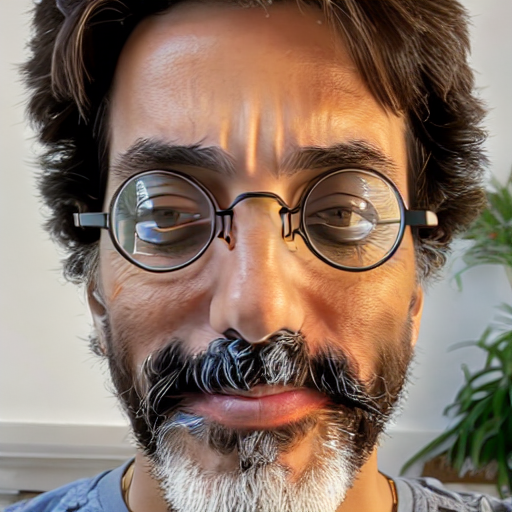

In [14]:
noise = torch.randn(1, 4, 64, 64, device=device, dtype=torch_dtype)
prompt = "a photo of sks person"
negative_prompt = "blurry, low quality, distorted, bad anatomy"

with torch.no_grad():
    output_tensors = sd(
        prompts=[prompt],
        noise=noise,
        num_steps=50,
        device=device,
        guidance_scale=7.5,
        negative_prompts=[negative_prompt]
    )

image_tensor = (output_tensors[0] / 2.0 + 0.5).clamp(0, 1)
image_numpy = image_tensor.cpu().permute(1, 2, 0).numpy()
image_numpy = (image_numpy * 255.0).astype("uint8")
image = Image.fromarray(image_numpy)

output_name = "sks_person_custom_generation.png"
image.save(output_name)
image

In [15]:
!python merge_weight_lora.py

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Loading weights: 100% 196/196 [00:00<00:00, 4140.48it/s]
[CLIP] All keys loaded successfully ✅
[VAE] All keys loaded successfully ✅
[UNet] All keys loaded successfully ✅
Successfully exported standard checkpoint to: /content/drive/MyDrive/ComfyUI/models/checkpoints/my_lora_merged_model.safetensors
